In [ ]:
import pandas as pd
import os 

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

 # Load the dataset
test = "test_3"
df = pd.read_csv('./data/'+test+'/robot_log.csv', delimiter=';')
#df


image_dir = 'data/'+test+'/IMG/'
#df['Path'] = df['Path'].apply(lambda p: os.path.basename(p)).replace('\\', '/')
df['Path'] = df['Path'].str.replace(r'^C:\\Users\\Chris SB\\Downloads\\IMG\\', '', regex=True)
## Update the Path column to have full paths
df['Path'] = df['Path'].apply(lambda x: os.path.join(image_dir, x))
df = df.sample(frac=1).reset_index(drop=True)


img_path = df['Path'][20]
print(img_path)
print(df['SteerAngle'][20])
print(df['Throttle'][20])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

df['SteerAngle'].hist(bins=50)
plt.title('Steering Angle Distribution')
plt.show()

df['Throttle'].hist(bins=50)
plt.title('Throttle Distribution')
plt.show()

 # Select relevant columns
df = df[['Path', 'SteerAngle', 'Throttle']]


  import numpy as np
  import cv2
  from tensorflow.keras.utils import Sequence

import random

def augment_image(image):
    # Random brightness (in HSV)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    ratio = 0.4 + np.random.uniform()  # random brightness factor
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * ratio, 0, 255)
    image = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    # Random horizontal flip
    if random.random() < 0.5:
        image = cv2.flip(image, 1)  # flip image
        flipped = True
    else:
        flipped = False

    return image, flipped


  class DataGenerator(Sequence):
      def __init__(self, dataframe, batch_size=32, dim=(66, 200), shuffle=True, augment=False):
          self.df = dataframe
          self.batch_size = batch_size
          self.dim = dim
          self.shuffle = shuffle
          self.augment = augment 
          self.on_epoch_end()
          

      def __len__(self):
          return int(np.floor(len(self.df) / self.batch_size))

      def __getitem__(self, index):
          indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
          batch_data = self.df.iloc[indexes]
          X, y = self.__data_generation(batch_data)
          return X, y

      def on_epoch_end(self):
          self.indexes = np.arange(len(self.df))
          if self.shuffle:
              np.random.shuffle(self.indexes)

      def __data_generation(self, batch_data):
          images = []
          steer_angles = []
          throttles = []
          for _, row in batch_data.iterrows():
              img = cv2.imread(row['Path'])
              img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              img = cv2.resize(img, (self.dim[1], self.dim[0]))  # ✅ width first, then height


              if self.augment:
                img, flipped = augment_image(img)
                if flipped:
                # If we flipped the image, we should flip the steering angle too
                    steer = -row['SteerAngle']
                else:
                    steer = row['SteerAngle']
              else:
                steer = row['SteerAngle']

              images.append(img)
              steer_angles.append(steer) #append(row['SteerAngle'])
              throttles.append(row['Throttle'])
              
          X = np.array(images, dtype=np.float32) / 255.0  # Normalize
          y = np.array(list(zip(steer_angles, throttles)), dtype=np.float32)
          return X, y

from sklearn.model_selection import train_test_split

# Split the dataset
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Parameters
batch_size = 32
image_size = (66, 200)

# Generators
training_generator = DataGenerator(train_df, batch_size=batch_size, dim=image_size, augment=True)
validation_generator = DataGenerator(val_df, batch_size=batch_size, dim=image_size, augment=False)

# Show random images from validation_generator
X_val, y_val = validation_generator.__getitem__(0)

for i in range(min(5, X_val.shape[0])):
    plt.imshow(X_val[i])
    plt.title(f"Steer: {y_val[i][0]:.2f}, Throttle: {y_val[i][1]:.2f}")
    plt.axis('off')
    plt.show()

X_test, y_test = training_generator.__getitem__(0)
print(X_test.shape)  # Should be (batch_size, 66, 200, 3)
print(y_test.shape)  # Should be (batch_size, 2)
print(X_test.dtype)  # Should be float32
print(y_test.dtype)  # Should be float32

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam

# Build the model
def build_model():
    model = Sequential()

    # Normalization
    model.add(Lambda(lambda x: x / 255.0, input_shape=(66, 200, 3)))

    # Convolutional layers
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='relu'))
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='relu'))
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))

    # Fully connected layers
    model.add(Flatten())
    model.add(Dense(1164, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(50, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(10, activation='relu'))
    model.add(Dropout(0.5))

    # Output layer: 2 values (SteerAngle, Throttle)
    model.add(Dense(2))  # Linear activation by default

    return model

    # ----------------------------
# 2. Define custom loss function
# ----------------------------
def custom_loss(y_true, y_pred):
    steer_loss = tf.reduce_mean(tf.square(y_true[:, 0] - y_pred[:, 0]))
    throttle_loss = tf.reduce_mean(tf.square(y_true[:, 1] - y_pred[:, 1]))
    return 0.5 * steer_loss + 0.5 * throttle_loss



model = build_model()
model.compile(optimizer=Adam(learning_rate=1e-4), loss=custom_loss)

X_test, y_test = training_generator.__getitem__(0)
print(X_test.shape)  # Should be (batch_size, 66, 200, 3)
print(y_test.shape)  # Should be (batch_size, 2)
print(X_test.dtype)  # Should be float32
print(y_test.dtype)  # Should be float32

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',        # Watch the validation loss
    patience=5,                # Wait 3 epochs after last improvement
    restore_best_weights=True # Use the best model, not the last one
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


model.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=30,                 # Set a high cap
    callbacks =[lr_scheduler]
)

# Plot training & validation loss
plt.plot(model.history.history['loss'], label='Train Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

val_loss = model.evaluate(validation_generator)
print(f"Validation MSE Loss: {val_loss}")

X_sample, y_true = validation_generator.__getitem__(0)  # get one batch
y_pred = model.predict(X_sample)

# Show first prediction vs. ground truth
print("Prediction (Steer, Throttle):", y_pred[0])
print("Actual (Steer, Throttle):", y_true[0])

# Collect all predictions and true labels
y_preds = []
y_trues = []

for i in range(len(validation_generator)):
    X_batch, y_batch = validation_generator[i]
    preds = model.predict(X_batch)
    y_preds.append(preds)
    y_trues.append(y_batch)

# Combine all batches
y_preds = np.vstack(y_preds)
y_trues = np.vstack(y_trues)

import matplotlib.pyplot as plt

# Plot SteerAngle
plt.figure(figsize=(10, 7))
plt.plot(y_trues[:, 0], label='Actual SteerAngle', linewidth=2)
plt.plot(y_preds[:, 0], label='Predicted SteerAngle', linestyle='--')
plt.title("Predicted vs Actual - SteerAngle")
plt.xlabel("Sample")
plt.ylabel("SteerAngle")
plt.legend()
plt.grid(True)
plt.show()

# Plot Throttle
plt.figure(figsize=(10, 7))
plt.plot(y_trues[:, 1], label='Actual Throttle', linewidth=2)
plt.plot(y_preds[:, 1], label='Predicted Throttle', linestyle='--')
plt.title("Predicted vs Actual - Throttle")
plt.xlabel("Sample")
plt.ylabel("Throttle")
plt.legend()
plt.grid(True)
plt.show()


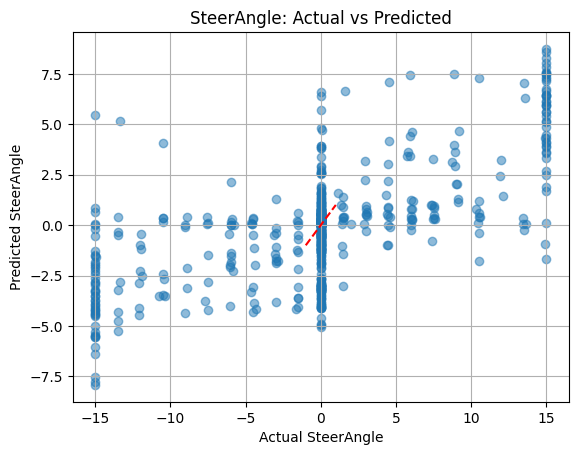

In [41]:
plt.scatter(y_trues[:, 0], y_preds[:, 0], alpha=0.5)
plt.xlabel("Actual SteerAngle")
plt.ylabel("Predicted SteerAngle")
plt.title("SteerAngle: Actual vs Predicted")
plt.grid(True)
plt.plot([-1, 1], [-1, 1], 'r--')  # Ideal line
plt.show()